In [1]:
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('stopwords'); nltk.download('punkt')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Krishna\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Krishna\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [2]:
df = pd.read_csv("IMDB Dataset.csv")    # from Kaggle
df['label'] = (df['sentiment'] == 'positive').astype(int)

In [6]:
stop_words = set(stopwords.words('english'))
def clean(text):
    text = re.sub(r'<.*?>', ' ', text)       # remove HTML
    text = re.sub(r'[^a-zA-Z ]', ' ', text)  # keep letters only
    tokens = text.lower().split()
    return ' '.join(w for w in tokens if w not in stop_words)

df['clean'] = df['review'].apply(clean)

In [7]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean'])
y = df['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
clf = MultinomialNB(alpha=0.1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [10]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Accuracy: 0.8674
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87      5000
    Positive       0.86      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



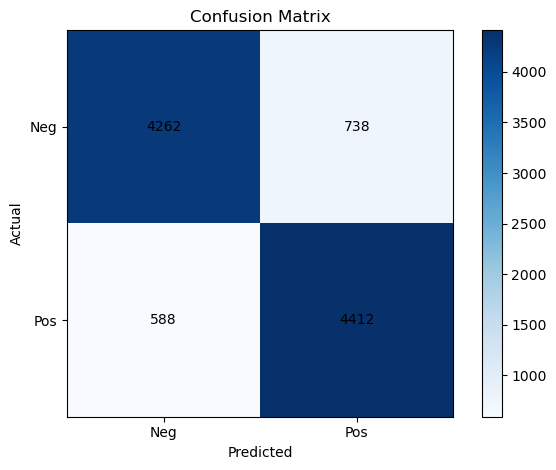

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.xticks([0,1],['Neg','Pos']); plt.yticks([0,1],['Neg','Pos'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha='center',va='center')
plt.title("Confusion Matrix"); plt.tight_layout(); plt.show()